In [72]:
print("Employee Burnout Prediction using Machine Learning")

Employee Burnout Prediction using Machine Learning


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import files
uploaded = files.upload()

Saving project.csv to project.csv


In [5]:
df = pd.read_csv('project.csv')

In [6]:
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [7]:
df.shape

(22750, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [9]:
df.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


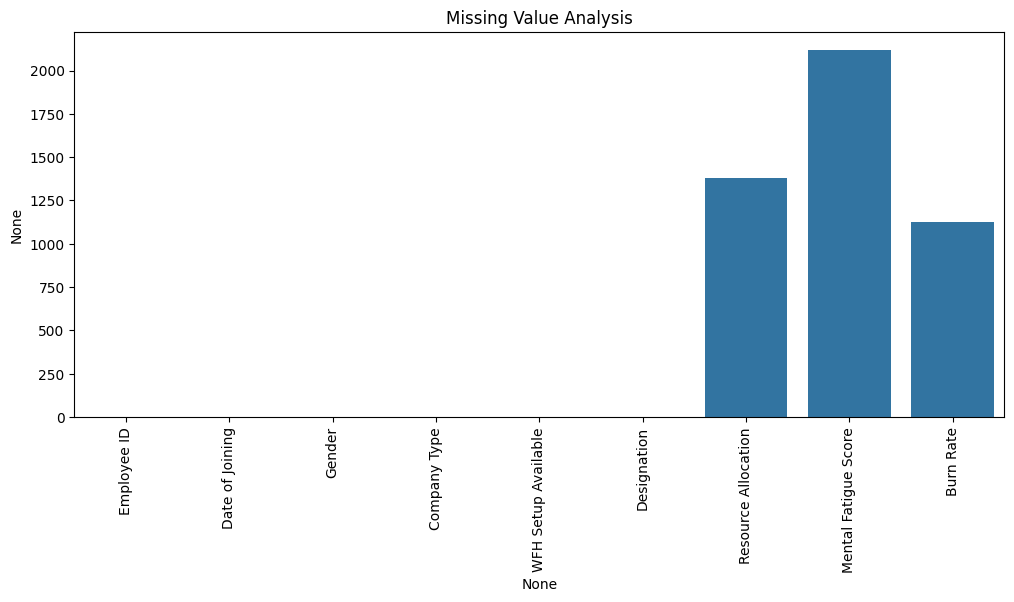

In [10]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=df.columns,
    y=df.isnull().sum()
)

plt.xticks(rotation=90)
plt.title("Missing Value Analysis")

plt.show()

In [11]:
df.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [12]:
df = df.dropna()

In [13]:
df.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop(['Employee ID'], axis=1)

In [16]:
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])

In [17]:
df['Joining Year'] = df['Date of Joining'].dt.year

In [18]:
df['Joining Month'] = df['Date of Joining'].dt.month

In [19]:
df = df.drop(['Date of Joining'], axis=1)

In [20]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

In [21]:
df['Company Type'] = le.fit_transform(df['Company Type'])

In [22]:
df['WFH Setup Available'] = le.fit_transform(df['WFH Setup Available'])

In [23]:
df.head()

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Joining Year,Joining Month
0,0,1,0,2.0,3.0,3.8,0.16,2008,9
1,1,1,1,1.0,2.0,5.0,0.36,2008,11
3,1,1,1,1.0,1.0,2.6,0.20,2008,11
4,0,1,0,3.0,7.0,6.9,0.52,2008,7
5,1,0,1,2.0,4.0,3.6,0.29,2008,11


In [24]:
df.shape

(18590, 9)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18590 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                18590 non-null  int64  
 1   Company Type          18590 non-null  int64  
 2   WFH Setup Available   18590 non-null  int64  
 3   Designation           18590 non-null  float64
 4   Resource Allocation   18590 non-null  float64
 5   Mental Fatigue Score  18590 non-null  float64
 6   Burn Rate             18590 non-null  float64
 7   Joining Year          18590 non-null  int32  
 8   Joining Month         18590 non-null  int32  
dtypes: float64(4), int32(2), int64(3)
memory usage: 1.3 MB


In [26]:
df.isnull().sum()

,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0
Joining Year,0
Joining Month,0


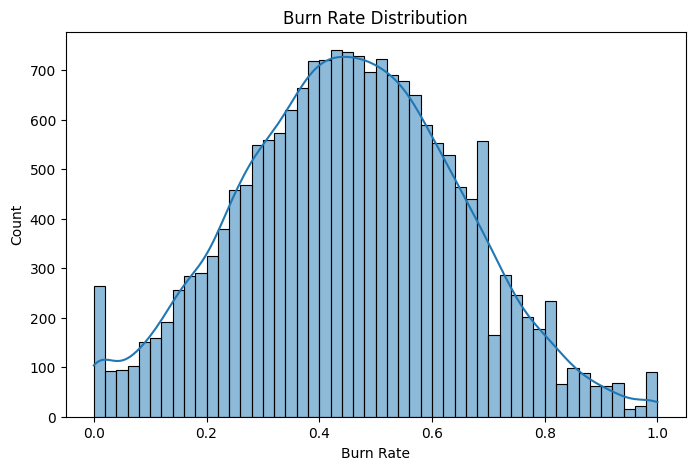

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Burn Rate"],
    kde=True
)

plt.title("Burn Rate Distribution")

plt.show()

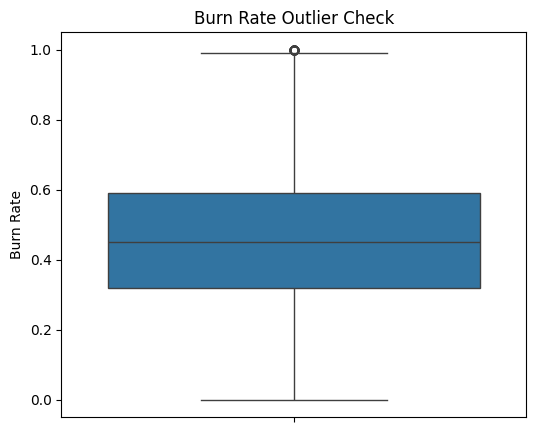

In [36]:
plt.figure(figsize=(6,5))

sns.boxplot(
    y=df["Burn Rate"]
)

plt.title("Burn Rate Outlier Check")

plt.show()

In [27]:
correlation = df.corr(numeric_only=True)
burn_corr = correlation['Burn Rate'].drop(['Burn Rate', 'Joining Year'])
burn_corr = burn_corr.sort_values(ascending=True)
print(burn_corr)

WFH Setup Available    -0.307168
Joining Month           0.000342
Company Type            0.005904
Gender                  0.156577
Designation             0.736412
Resource Allocation     0.855005
Mental Fatigue Score    0.944389
Name: Burn Rate, dtype: float64


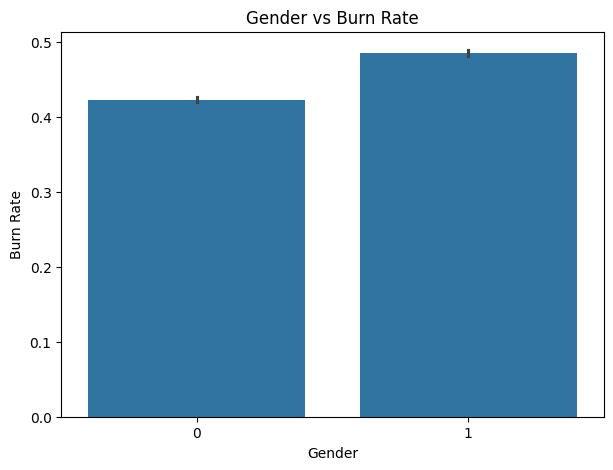

In [37]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Gender",
    y="Burn Rate"
)

plt.title("Gender vs Burn Rate")

plt.show()

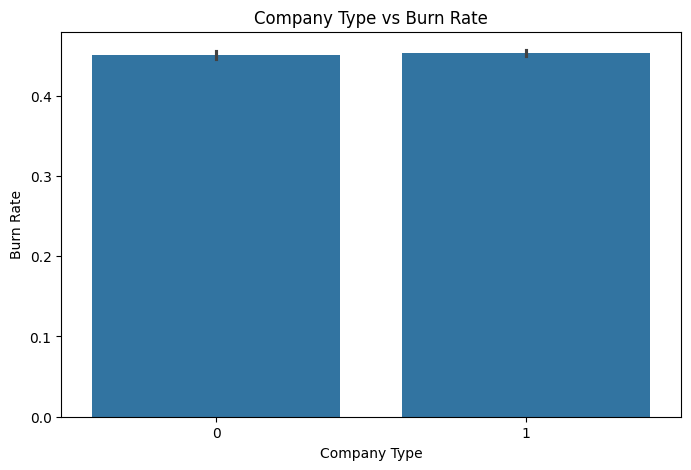

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Company Type",
    y="Burn Rate"
)

plt.title("Company Type vs Burn Rate")

plt.show()

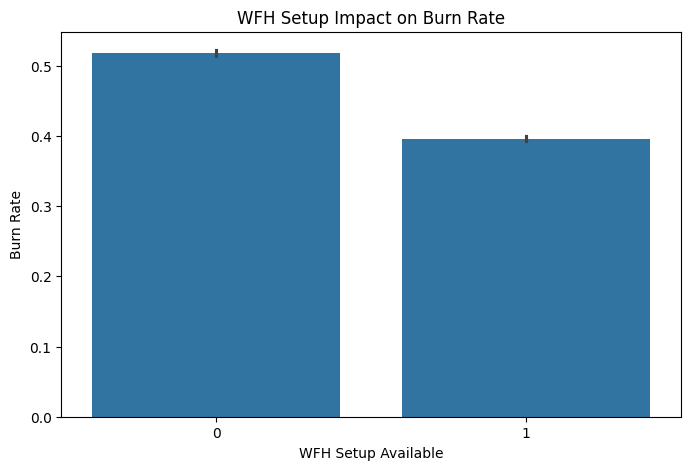

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="WFH Setup Available",
    y="Burn Rate"
)

plt.title("WFH Setup Impact on Burn Rate")

plt.show()

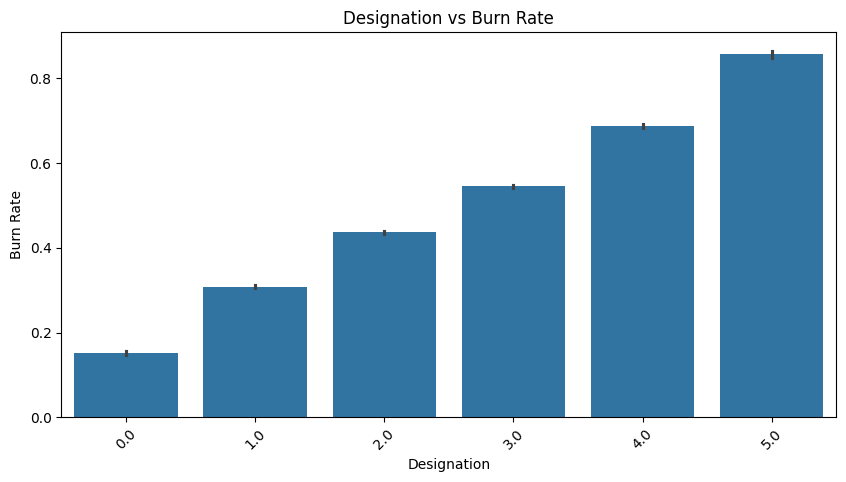

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Designation",
    y="Burn Rate"
)

plt.xticks(rotation=45)

plt.title("Designation vs Burn Rate")

plt.show()

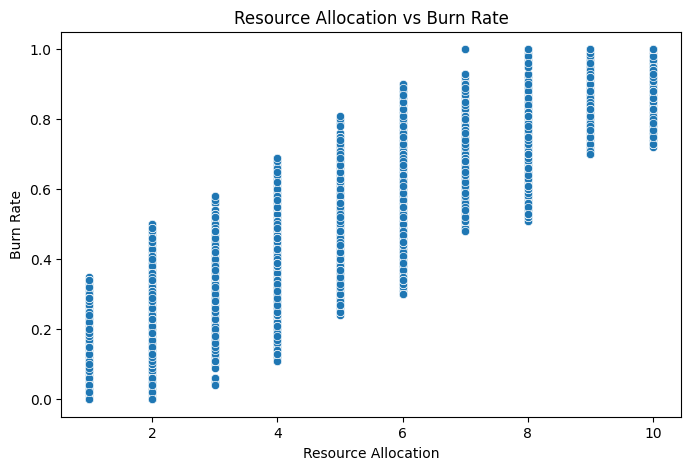

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Resource Allocation",
    y="Burn Rate"
)

plt.title("Resource Allocation vs Burn Rate")

plt.show()

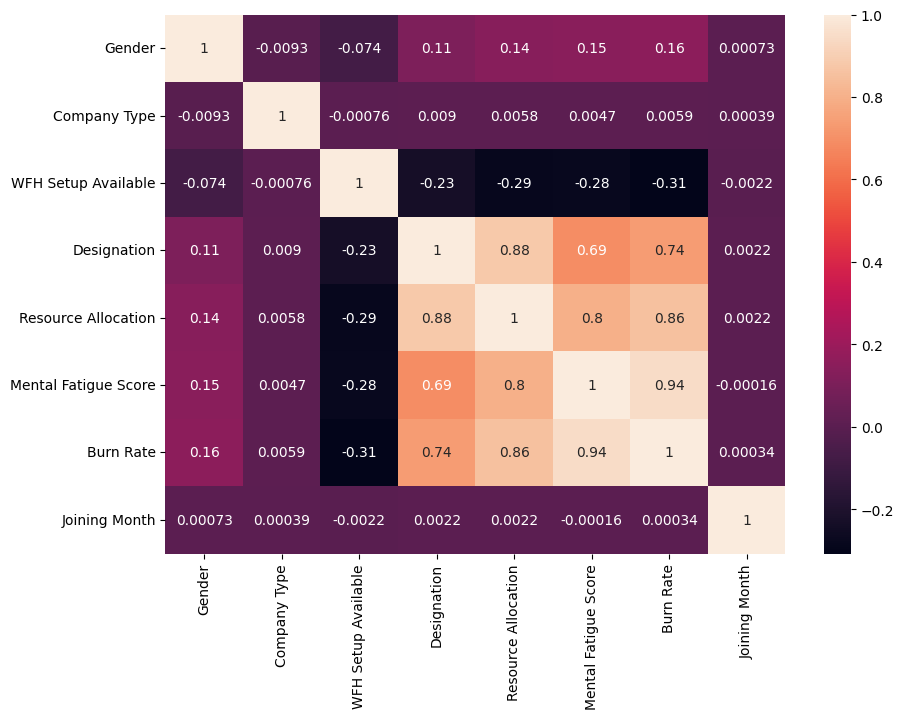

In [28]:
df=df.drop('Joining Year',axis=1)
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

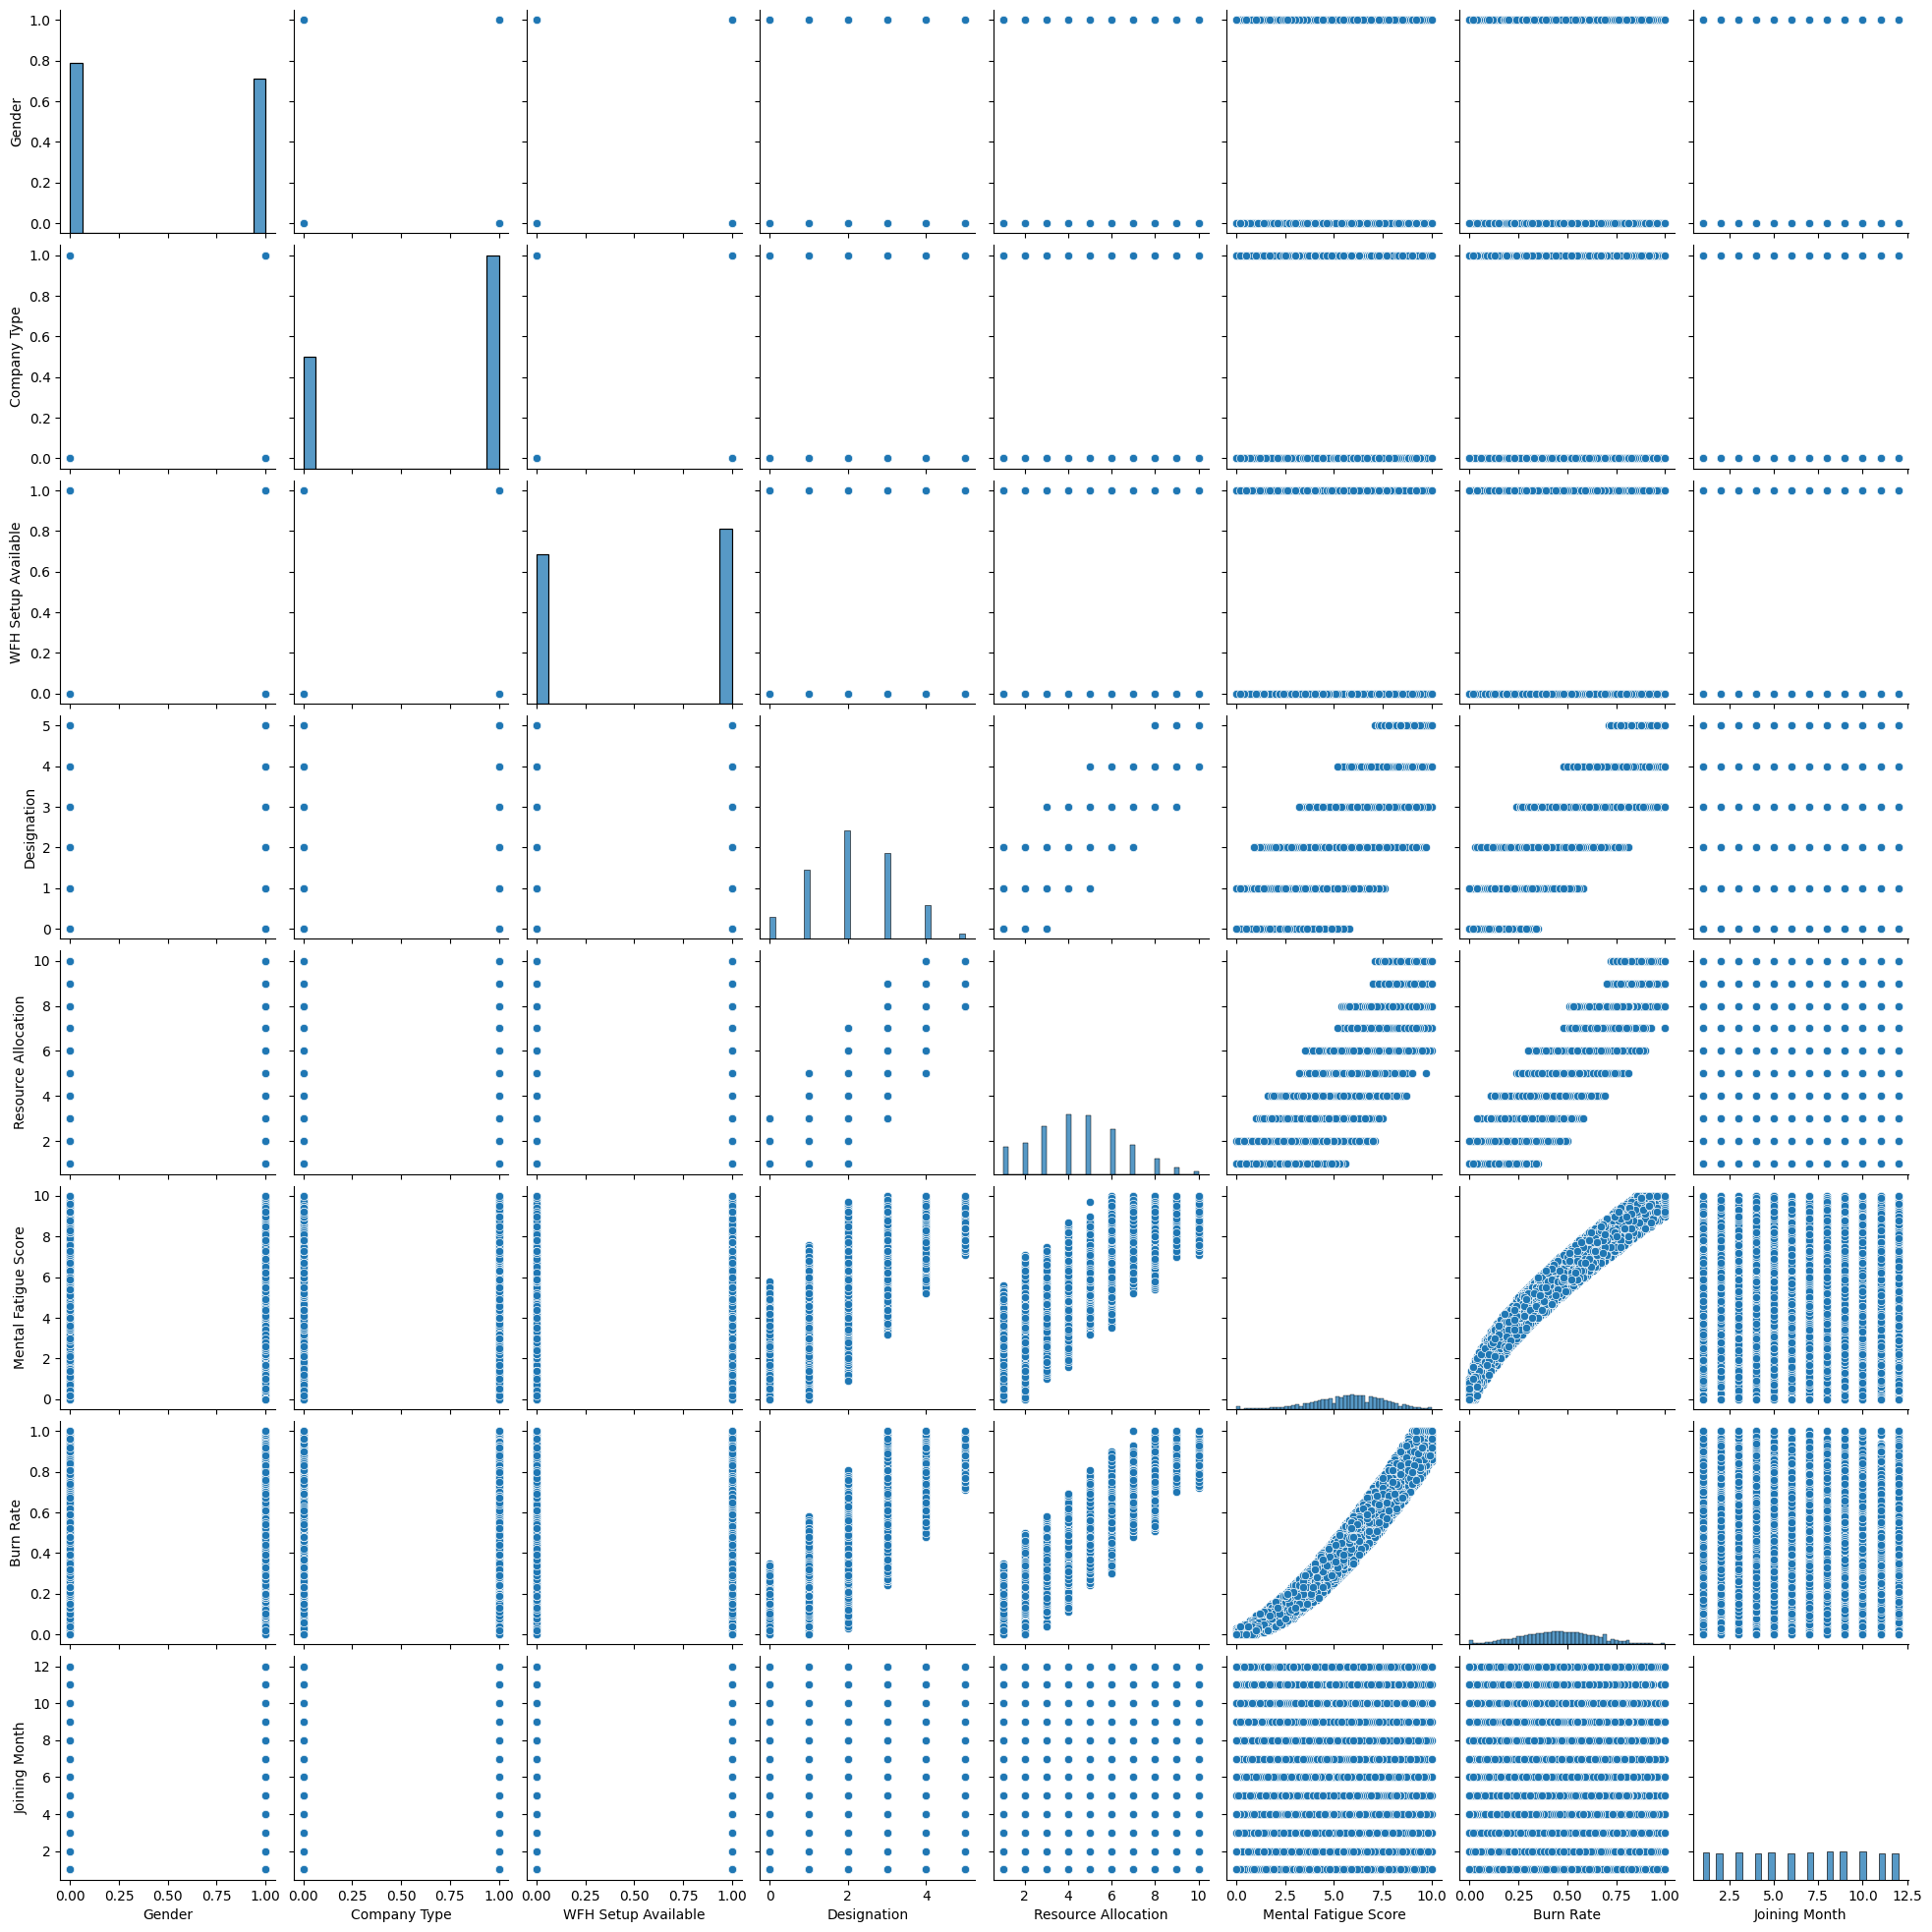

In [47]:
sns.pairplot(df)

plt.show()

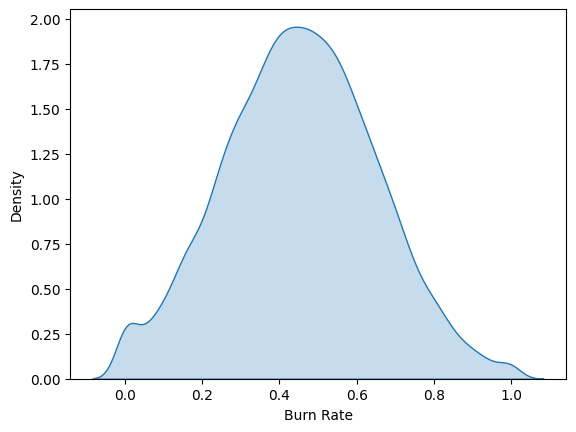

In [48]:
sns.kdeplot(df['Burn Rate'], fill=True)

plt.show()

In [43]:
df.skew(numeric_only=True)

,0
Gender,0.097380
Company Type,-0.651565
WFH Setup Available,-0.158659
Designation,0.082965
Resource Allocation,0.200141
Mental Fatigue Score,-0.438433
Burn Rate,0.041139
Joining Month,-0.018611


In [44]:
df.kurtosis(numeric_only=True)

,0
Gender,-1.990731
Company Type,-1.575632
WFH Setup Available,-1.975040
Designation,-0.413096
Resource Allocation,-0.478654
Mental Fatigue Score,0.178369
Burn Rate,-0.258264
Joining Month,-1.210695


In [45]:
df.cov(numeric_only=True)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Joining Month
Gender,0.249422,-0.002206,-0.018351,0.062542,0.144086,0.139808,0.015471,0.001252
Company Type,-0.002206,0.226028,-0.000179,0.004842,0.005633,0.004289,0.000555,0.000640
WFH Setup Available,-0.018351,-0.000179,0.248450,-0.130957,-0.290877,-0.265824,-0.030292,-0.003824
Designation,0.062542,0.004842,-0.130957,1.284023,2.034179,1.505589,0.165096,0.008477
Resource Allocation,0.144086,0.005633,-0.290877,2.034179,4.181405,3.140066,0.345908,0.015220
Mental Fatigue Score,0.139808,0.004289,-0.265824,1.505589,3.140066,3.688500,0.358845,-0.001035
Burn Rate,0.015471,0.000555,-0.030292,0.165096,0.345908,0.358845,0.039144,0.000232
Joining Month,0.001252,0.000640,-0.003824,0.008477,0.015220,-0.001035,0.000232,11.819838


In [53]:
X = df.drop("Burn Rate", axis=1)

y = df["Burn Rate"]


print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (18590, 7)
Target Shape: (18590,)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)
print(X_test.shape)

(14872, 7)
(3718, 7)


In [55]:
scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


print("Scaling Completed")

Scaling Completed


In [56]:
models = {

"Linear Regression":
LinearRegression(),

"Decision Tree":
DecisionTreeRegressor(
    random_state=42
),

"Random Forest":
RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

}


models

{'Linear Regression': LinearRegression(),
 'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42)}

In [57]:
results = {}


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )


    prediction = model.predict(
        X_test
    )


    r2 = r2_score(
        y_test,
        prediction
    )


    mae = mean_absolute_error(
        y_test,
        prediction
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )


    results[name] = [
        r2,
        mae,
        rmse
    ]


    print("----------------")
    print(name)
    print("R2 Score :",r2)
    print("MAE :",mae)
    print("RMSE :",rmse)

----------------
Linear Regression
R2 Score : 0.9202018178184184
MAE : 0.04552644112107805
RMSE : 0.05535911976995083
----------------
Decision Tree
R2 Score : 0.8570166456840669
MAE : 0.057386722252106864
RMSE : 0.07410293638649516
----------------
Random Forest
R2 Score : 0.9095426539332743
MAE : 0.04682323558337544
RMSE : 0.058940606154870324


In [58]:
result_df = pd.DataFrame(
    results,
    index=[
        "R2 Score",
        "MAE",
        "RMSE"
    ]
)


result_df

,Linear Regression,Decision Tree,Random Forest
R2 Score,0.920202,0.857017,0.909543
MAE,0.045526,0.057387,0.046823
RMSE,0.055359,0.074103,0.058941


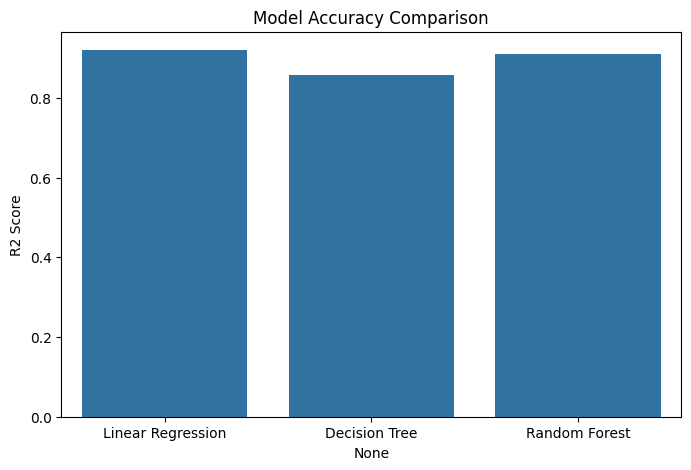

In [59]:
plt.figure(figsize=(8,5))


sns.barplot(
    x=result_df.columns,
    y=result_df.loc["R2 Score"]
)


plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "R2 Score"
)

plt.show()

In [60]:
best_model_name = result_df.loc["R2 Score"].idxmax()

best_model = models[best_model_name]


print(
    "Best Model:",
    best_model_name
)

Best Model: Linear Regression


In [62]:
rf_model = models["Random Forest"]


importance = pd.DataFrame({

"Feature":
X.columns,

"Importance":
rf_model.feature_importances_

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance

,Feature,Importance
5,Mental Fatigue Score,0.912894
4,Resource Allocation,0.034976
6,Joining Month,0.024982
3,Designation,0.008577
0,Gender,0.006386
1,Company Type,0.006198
2,WFH Setup Available,0.005988


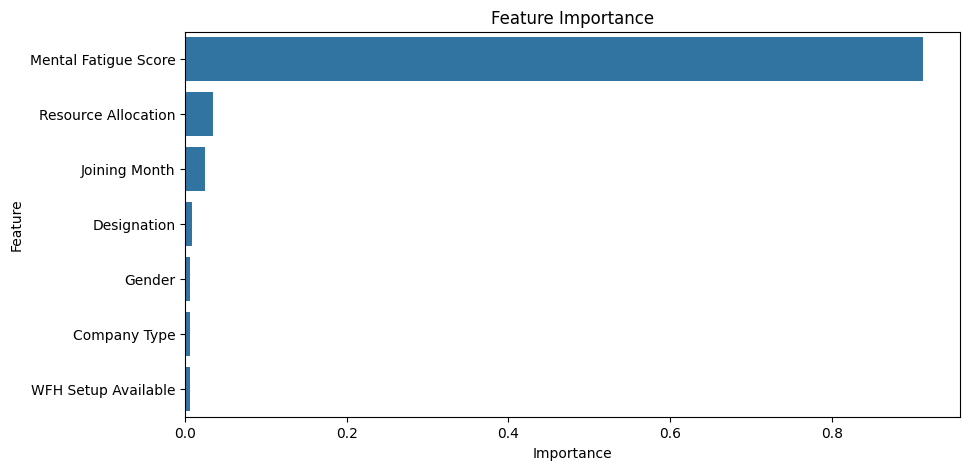

In [63]:
plt.figure(figsize=(10,5))


sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)


plt.title(
    "Feature Importance"
)


plt.show()

In [64]:
import pickle


pickle.dump(
    best_model,
    open(
        "burnout_model.pkl",
        "wb"
    )
)


pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)


print("Model Saved Successfully")

Model Saved Successfully


In [65]:
loaded_model = pickle.load(
    open(
        "burnout_model.pkl",
        "rb"
    )
)

loaded_scaler = pickle.load(
    open(
        "scaler.pkl",
        "rb"
    )
)


print("Model Loaded")

Model Loaded


In [69]:
new_employee = np.array([[
    25,
    1,
    4,
    2,
    3,
    8,
    6
]])


new_employee = loaded_scaler.transform(
    new_employee
)


prediction = loaded_model.predict(
    new_employee
)


print(
    "Predicted Burn Rate:",
    prediction[0]
)

Predicted Burn Rate: 0.6562133480622355


In [67]:
rate = prediction[0]


if rate >= 0.6:
    print("High Burnout Risk")

elif rate >= 0.3:
    print("Medium Burnout Risk")

else:
    print("Low Burnout Risk")

Low Burnout Risk


In [71]:
print("""
Conclusion:

Random Forest achieved better performance compared to other models.

Important factors affecting employee burnout:
- Mental Fatigue Score
- Resource Allocation

This model helps to identify burnout risk.
""")


Conclusion:

Random Forest achieved better performance compared to other models.

Important factors affecting employee burnout:
- Mental Fatigue Score
- Resource Allocation

This model helps to identify burnout risk.

